# Libraries

In [1]:
import tensorflow as tf
from tensorflow import keras
import os
import numpy as np
import matplotlib.pyplot as plt
seed=0
np.random.seed(seed) # fix random seed
tf.random.set_seed(seed)

2025-11-27 09:54:12.185653: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Load and process the data

In [20]:
from keras.datasets import mnist
def load_data():
    # input image dimensions
    img_rows, img_cols = 28, 28 # number of pixels 
    # output
    num_classes = 10 # 10 digits

    # the data, split between train and test sets
    (X_train, Y_train), (X_test, Y_test) = mnist.load_data()

    print('X_train shape:', X_train.shape)
    print('Y_train shape:', Y_train.shape)

    ### Example: to_categorical
    # Consider an array of 5 labels out of a set of 3 classes {0, 1, 2}:
    labels = np.array([0, 2, 1, 2, 0])
    # `to_categorical` converts this into a matrix with as many columns as there are classes.
    # The number of rows stays the same.
    keras.utils.to_categorical(labels)

    ### reshape and convert labels to be used with categorical entropy

    # reshape data, it could depend on Keras backend
    X_train = X_train.reshape(X_train.shape[0], img_rows*img_cols)
    X_test = X_test.reshape(X_test.shape[0], img_rows*img_cols)
    print('X_train shape:', X_train.shape)
    print('X_test shape:', X_test.shape)
    print()

    # cast to floats
    X_train = X_train.astype('float32')
    X_test = X_test.astype('float32')

    # rescale data in interval [0,1]
    X_train /= 255
    X_test /= 255

    # convert class vectors to binary class matrices, e.g. for use with categorical_crossentropy
    Y_train = keras.utils.to_categorical(Y_train, num_classes)
    Y_test = keras.utils.to_categorical(Y_test, num_classes)

    print('X_train shape:', X_train.shape)
    print('Y_train shape:', Y_train.shape)

    return (X_train, Y_train), (X_test, Y_test)


In [60]:
(X_train, Y_train), (X_test, Y_test)=load_data()


X_train shape: (60000, 28, 28)
Y_train shape: (60000,)
X_train shape: (60000, 784)
X_test shape: (10000, 784)

X_train shape: (60000, 784)
Y_train shape: (60000, 10)


### Define NN and it's architecture 

In [22]:
from keras.models import Sequential
from keras.layers import Dense, Dropout

def create_DNN():
    # instantiate model
    model = Sequential()
    # add a dense all-to-all relu layer
    model.add(Dense(400,input_shape=(img_rows*img_cols,), activation='relu'))
    # add a dense all-to-all relu layer
    model.add(Dense(100, activation='relu'))
    # apply dropout with rate 0.5
    model.add(Dropout(0.5))
    # soft-max layer
    model.add(Dense(num_classes, activation='softmax'))
    
    return model

print('Model architecture created successfully!')

Model architecture created successfully!


### choose optimizer and cost function

In [23]:
from keras.optimizers import SGD, Adam, RMSprop, Adagrad, Adadelta, Adam, Adamax, Nadam

def compile_model(optimizer:str):
    # create the model
    model=create_DNN()
    # compile the model
    model.compile(loss=keras.losses.categorical_crossentropy,
                  optimizer=optimizer,
                  metrics=['acc'])
    return model

print('Model compiled successfully and ready to be trained.')

Model compiled successfully and ready to be trained.


### Step 5: evaluate performance on unseen data 

# Exercise 12.1


In [26]:
nepochs=20
batch_size = 32

## SGD

In [32]:
model_sgd = compile_model('sgd')

# train DNN and store training info in history
sgd_hist = model_sgd.fit(X_train, Y_train,
          batch_size=batch_size,
          epochs=nepochs,
          shuffle=True, # a good idea is to shuffle input before at each epoch
          verbose=0,
          validation_data=(X_test, Y_test))

/home/td/miniconda3/envs/dl/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



## adam

In [28]:
print('ADAM')

model_adam=compile_model('adam')

adam_hist=model_adam.fit(X_train, Y_train,
          batch_size=32,
          epochs=nepochs,
          shuffle=True, # a good idea is to shuffle input before at each epoch
          verbose=0,
          validation_data=(X_test, Y_test))

ADAM


/home/td/miniconda3/envs/dl/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## RMSprop

In [29]:
print('RMSprop')
model_rms=compile_model('rmsprop')

rms_hist=model_rms.fit(X_train, Y_train,
          batch_size=batch_size,
          epochs=nepochs,
          shuffle=True, # a good idea is to shuffle input before at each epoch
          verbose=0,
          validation_data=(X_test, Y_test))

RMSprop


/home/td/miniconda3/envs/dl/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# ADAMAX

In [30]:
print('adamax')
model_admx=compile_model('adamax')

admx_hist=model_admx.fit(X_train, Y_train,
          batch_size=batch_size,
          epochs=nepochs,
          shuffle=True, # a good idea is to shuffle input before at each epoch
          verbose=0,
          validation_data=(X_test, Y_test))

adamax


/home/td/miniconda3/envs/dl/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
def evaluate_model(model, X_test, Y_test):
    score = model.evaluate(X_test, Y_test, verbose=1)
    print()
    print('\tTest loss:', score[0])
    print('\tTest accuracy:', score[1])

    return score

SGD
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9715 - loss: 0.0884

	Test loss: 0.07467494159936905
	Test accuracy: 0.975600004196167
Adam
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9787 - loss: 0.1592

	Test loss: 0.1257559061050415
	Test accuracy: 0.9815000295639038
RMS
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9737 - loss: 0.2797

	Test loss: 0.22997719049453735
	Test accuracy: 0.9772999882698059
Adamax
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9799 - loss: 0.0747

	Test loss: 0.06233464181423187
	Test accuracy: 0.9833999872207642


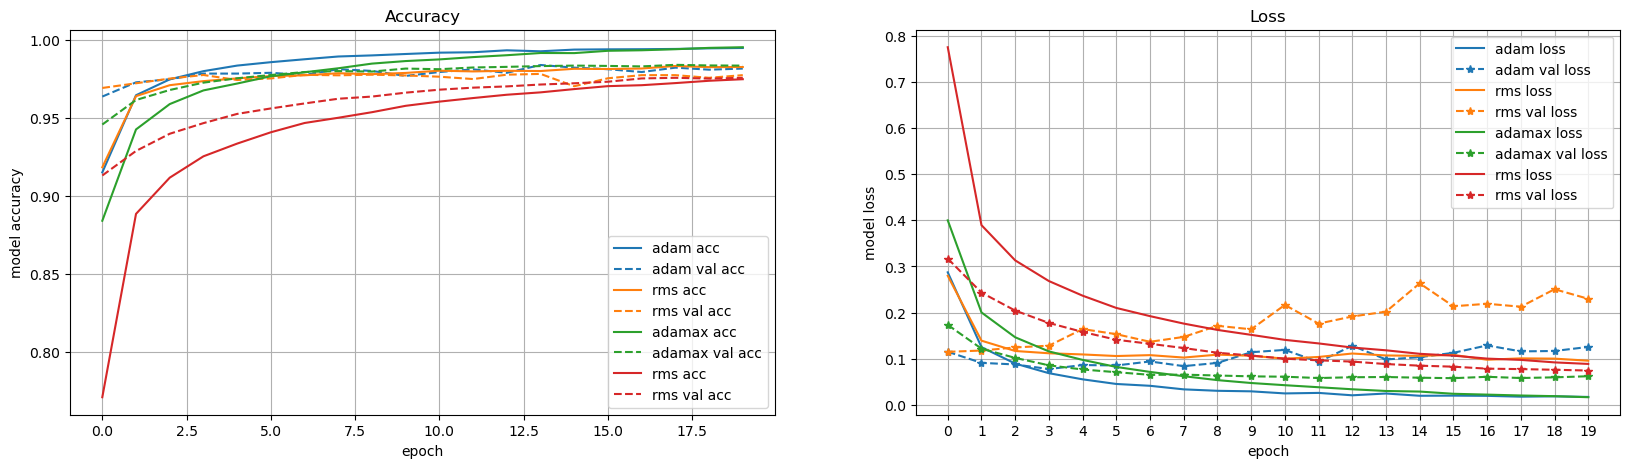

In [61]:
# evaluate model
print('SGD')
evaluate_model(model_sgd, X_test=X_test, Y_test=Y_test)
print('Adam')
evaluate_model(model_adam, X_test=X_test, Y_test=Y_test)
print('RMS')
evaluate_model(model_rms, X_test=X_test, Y_test=Y_test)
print('Adamax')
evaluate_model(model_admx, X_test=X_test, Y_test=Y_test)

# look into training history

fig, ax = plt.subplots(1,2,figsize=(20,5))

# summarize history for accuracy
ax[0].set_title('Accuracy')
ax[0].plot(adam_hist.history['acc'], label='adam acc',c='C0')
ax[0].plot(adam_hist.history['val_acc'], label='adam val acc', ls='--',c='C0')

ax[0].plot(rms_hist.history['acc'], label='rms acc',c='C1')
ax[0].plot(rms_hist.history['val_acc'], label='rms val acc', ls='--',c='C1')

ax[0].plot(admx_hist.history['acc'], label='adamax acc',c='C2')
ax[0].plot(admx_hist.history['val_acc'], label='adamax val acc', ls='--',c='C2')

ax[0].plot(sgd_hist.history['acc'], label='rms acc',c='C3')
ax[0].plot(sgd_hist.history['val_acc'], label='rms val acc', ls='--',c='C3')

ax[0].set_xlabel('epoch')
ax[0].set_ylabel('model accuracy')
ax[0].grid()
ax[0].legend(loc='best')

# summarize history for loss
ax[1].set_title('Loss')
ax[1].plot(adam_hist.history['loss'], label='adam loss',c='C0')
ax[1].plot(adam_hist.history['val_loss'], label='adam val loss', marker='*', ls='--',c='C0')

ax[1].plot(rms_hist.history['loss'], label='rms loss',c='C1')
ax[1].plot(rms_hist.history['val_loss'], label='rms val loss', marker='*', ls='--',c='C1')

ax[1].plot(admx_hist.history['loss'], label='adamax loss',c='C2')
ax[1].plot(admx_hist.history['val_loss'], label='adamax val loss', marker='*', ls='--',c='C2')

ax[1].plot(sgd_hist.history['loss'], label='rms loss',c='C3')
ax[1].plot(sgd_hist.history['val_loss'], label='rms val loss', marker='*', ls='--',c='C3')

ax[1].set_ylabel('model loss')
ax[1].set_xlabel('epoch')
ax[1].set_xticks(adam_hist.epoch)
ax[1].grid()
ax[1].legend( loc='best')
plt.show()

In [54]:
def test_predictions(model, X_test,Y_test, title=''):
    predictions = model.predict(X_test)

    X_test = X_test.reshape(X_test.shape[0], img_rows, img_cols,1)

    fig=plt.figure(figsize=(15, 15))
    fig.suptitle(title, y=0.8) 
    for i in range(10):    
        ax = plt.subplot(2, 10, i + 1)    
        plt.imshow(X_test[i, :, :, 0], cmap='gray')    
        plt.title("Digit: {}\nPredicted:    {}".format(np.argmax(Y_test[i]), np.argmax(predictions[i])))    
        plt.axis('off') 
    plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


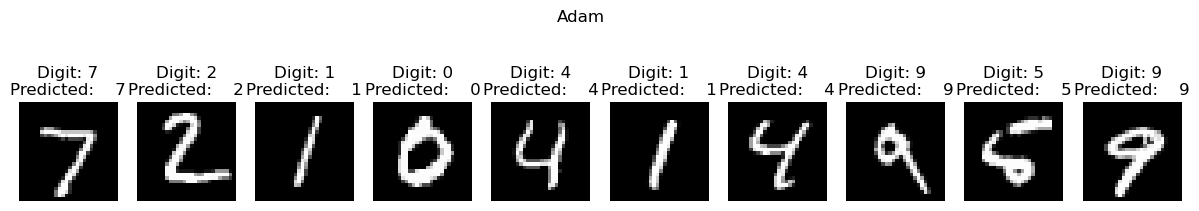

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


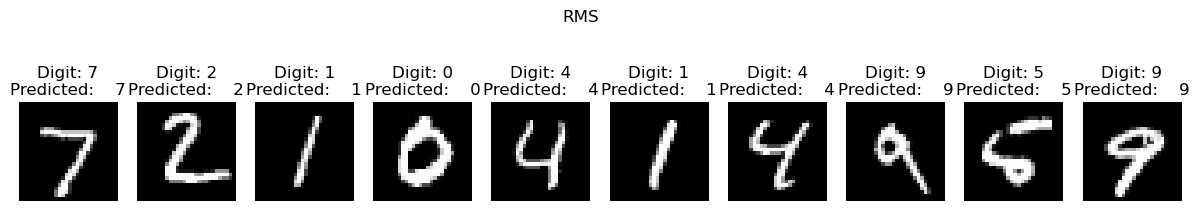

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


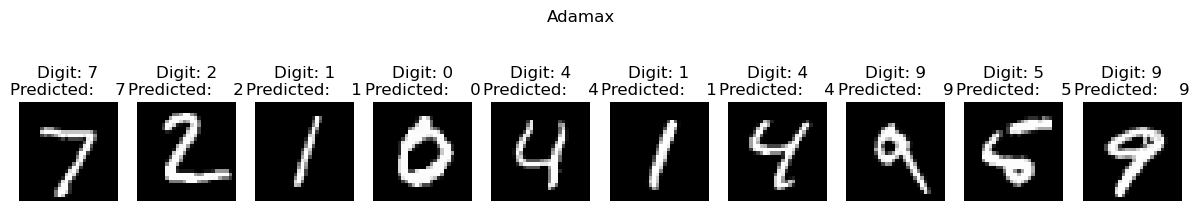

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


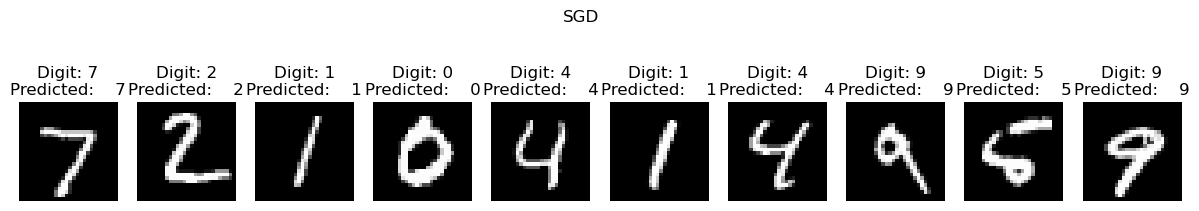

In [56]:
test_predictions(model=model_adam, X_test=X_test,Y_test=Y_test, title='Adam')
test_predictions(model=model_rms, X_test=X_test,Y_test=Y_test, title='RMS')
test_predictions(model=model_admx, X_test=X_test,Y_test=Y_test, title='Adamax')
test_predictions(model=model_sgd, X_test=X_test,Y_test=Y_test, title='SGD')


## Exercise 12.2

In [38]:
# you will need the following for Convolutional Neural Networks
from keras.layers import Flatten, Conv2D, MaxPooling2D, Input

In [ ]:
(X_train, Y_train), (X_test, Y_test)=load_data()


X_train shape: (60000, 28, 28)
Y_train shape: (60000,)
X_train shape: (60000, 784)
X_test shape: (10000, 784)

X_train shape: (60000, 784)
Y_train shape: (60000, 10)


In [66]:
# reshape data, depending on Keras backend
if keras.backend.image_data_format() == 'channels_first':
    X_train = X_train.reshape(X_train.shape[0], 1, img_rows, img_cols)
    X_test = X_test.reshape(X_test.shape[0], 1, img_rows, img_cols)
    input_shape = (1, img_rows, img_cols)
else:
    X_train = X_train.reshape(X_train.shape[0], img_rows, img_cols, 1)
    X_test = X_test.reshape(X_test.shape[0], img_rows, img_cols, 1)
    input_shape = (img_rows, img_cols, 1)
    
print('X_train shape:', X_train.shape)
print('Y_train shape:', Y_train.shape)
print()
print(X_train.shape[0], 'train samples')
print(X_test.shape[0], 'test samples')

X_train shape: (60000, 28, 28, 1)
Y_train shape: (60000, 10)

60000 train samples
10000 test samples


In [40]:
#THIS IS INCOMPLETE ... COMPLETE BEFORE EXECUTING IT

def create_CNN():
    # instantiate model
    model = Sequential()
    # add first convolutional layer with 10 filters (dimensionality of output space)
    model.add(Input(shape=(28,28,1)))
    model.add(Conv2D(10, kernel_size=(5, 5),
                     activation='relu',
                     input_shape=input_shape))
    #
    # ADD HERE SOME OTHER LAYERS AT YOUR WILL, FOR EXAMPLE SOME: Dropout, 2D pooling, 2D convolutional etc. ... 
    # remember to move towards a standard flat layer in the final part of your DNN,
    # and that we need a soft-max layer with num_classes=10 possible outputs
    #
    model.add(MaxPooling2D(
        pool_size=(2,2), strides=2
    ))

    model.add(Dropout(0.1))
    
    model.add(
        Conv2D(16, kernel_size=(5,5), strides=1, activation='relu')
    )
    model.add(MaxPooling2D(strides=2))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(10, activation='softmax'))
    # compile the model
    model.compile(loss=keras.losses.categorical_crossentropy,
                  optimizer='SGD',
                  metrics=['acc'])
    return model

In [67]:
# training parameters
batch_size = 32
epochs = 20

# create the deep conv net
model_CNN=create_CNN()
model_CNN.summary()
# train CNN
cnn_history=model_CNN.fit(X_train, Y_train,
          batch_size=batch_size,
          shuffle=True,
          epochs=epochs,
          verbose=1,
          validation_data=(X_test, Y_test))

# evaliate model
score = model_CNN.evaluate(X_test, Y_test, verbose=1)

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 10)     │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 12, 12, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 16)       │         4,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,462 (150.24 KB)

 Trainable params: 38,462 (150.24 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - acc: 0.6104 - loss: 1.2207 - val_acc: 0.9524 - val_loss: 0.1689
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - acc: 0.9462 - loss: 0.1780 - val_acc: 0.9680 - val_loss: 0.1012
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - acc: 0.9638 - loss: 0.1234 - val_acc: 0.9758 - val_loss: 0.0760
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - acc: 0.9705 - loss: 0.0988 - val_acc: 0.9801 - val_loss: 0.0592
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - acc: 0.9742 - loss: 0.0843 - val_acc: 0.9823 - val_loss: 0.0554
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - acc: 0.9773 - loss: 0.0723 - val_acc: 0.9853 - val_loss: 0.0461
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - acc: 0.9793 - loss: 0.0663 - val_acc: 0.9860 - val_loss: 0.0437
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - acc: 0.9819 - loss: 0.0592 - val_acc: 0.9865 - val_loss: 0.0419
Epoch 9/20
1875/1875 ━━━━━━━━━━━

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


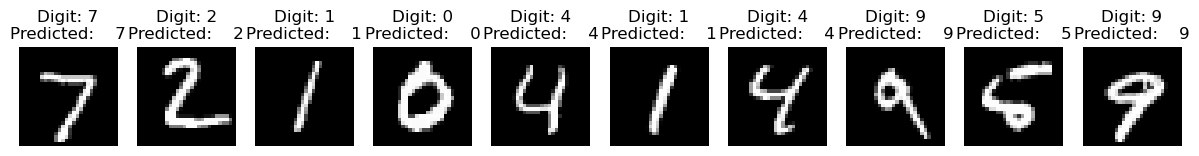

In [27]:
#X_test = X_test.reshape(X_test.shape[0], img_rows*img_cols)
predictions = model_CNN.predict(X_test)

X_test = X_test.reshape(X_test.shape[0], img_rows, img_cols,1)

plt.figure(figsize=(15, 15)) 
for i in range(10):    
    ax = plt.subplot(2, 10, i + 1)    
    plt.imshow(X_test[i, :, :, 0], cmap='gray')    
    plt.title("Digit: {}\nPredicted:    {}".format(np.argmax(Y_test[i]), np.argmax(predictions[i])))    
    plt.axis('off') 
plt.show()

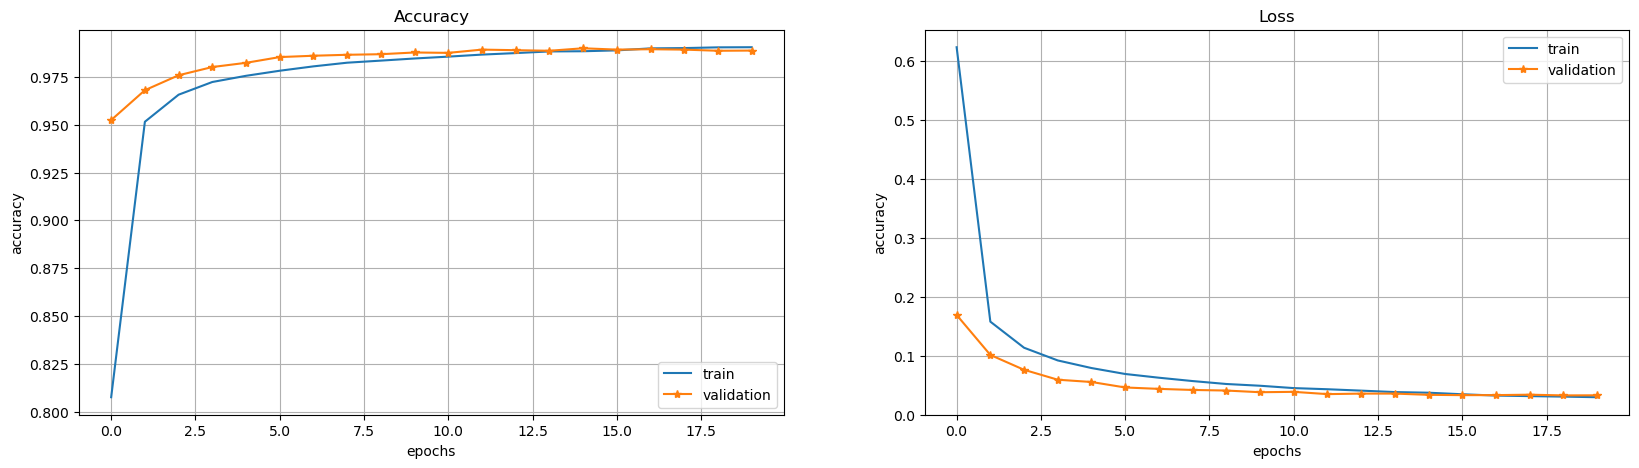

In [68]:
fig, ax = plt.subplots(1,2,figsize=(20,5))

ax[0].set_title('Accuracy')
ax[0].plot(cnn_history.epoch , cnn_history.history['acc'], label='train')
ax[0].plot(cnn_history.epoch ,cnn_history.history['val_acc'], label='validation', marker='*')
ax[0].grid()
ax[0].set_xlabel('epochs')
ax[0].set_ylabel('accuracy')
ax[0].legend()

ax[1].set_title('Loss')
ax[1].plot(cnn_history.epoch , cnn_history.history['loss'], label='train')
ax[1].plot(cnn_history.epoch ,cnn_history.history['val_loss'], label='validation', marker='*')
ax[1].grid()
ax[1].set_xlabel('epochs')
ax[1].set_ylabel('accuracy')
ax[1].legend()
plt.show()

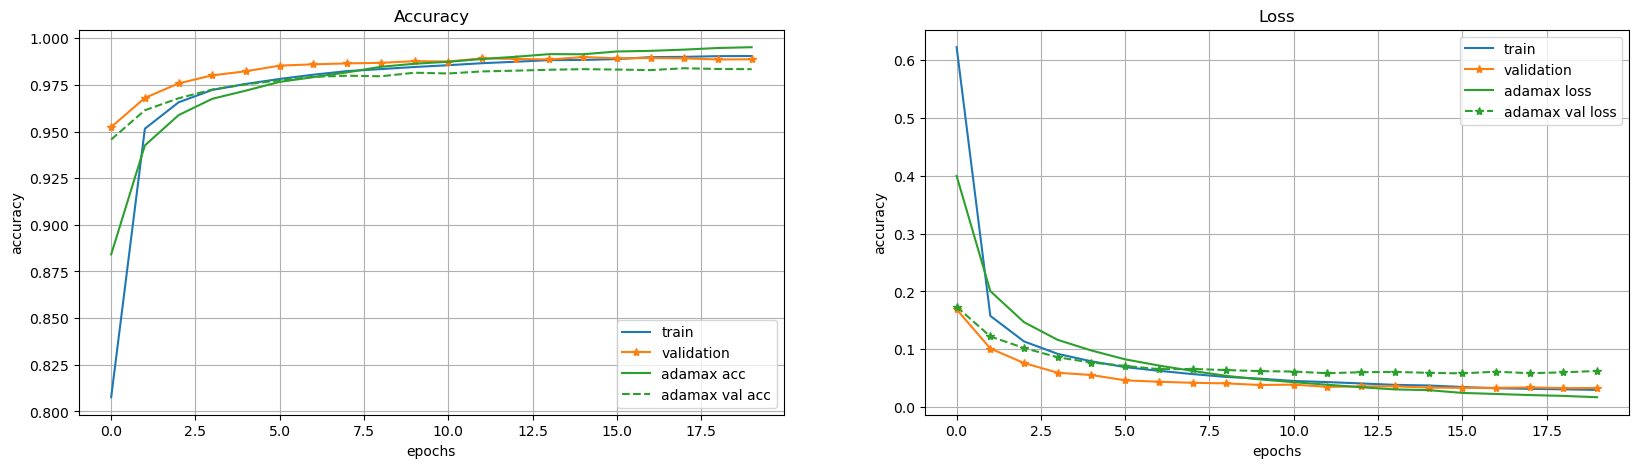

In [69]:
fig, ax = plt.subplots(1,2,figsize=(20,5))

ax[0].set_title('Accuracy')
ax[0].plot(cnn_history.epoch , cnn_history.history['acc'], label='train')
ax[0].plot(cnn_history.epoch ,cnn_history.history['val_acc'], label='validation', marker='*')
ax[0].plot(admx_hist.history['acc'], label='adamax acc',c='C2')
ax[0].plot(admx_hist.history['val_acc'], label='adamax val acc', ls='--',c='C2')


ax[0].grid()
ax[0].set_xlabel('epochs')
ax[0].set_ylabel('accuracy')
ax[0].legend()

ax[1].set_title('Loss')
ax[1].plot(cnn_history.epoch , cnn_history.history['loss'], label='train')
ax[1].plot(cnn_history.epoch ,cnn_history.history['val_loss'], label='validation', marker='*')
ax[1].plot(admx_hist.history['loss'], label='adamax loss',c='C2')
ax[1].plot(admx_hist.history['val_loss'], label='adamax val loss', marker='*', ls='--',c='C2')

ax[1].grid()
ax[1].set_xlabel('epochs')
ax[1].set_ylabel('accuracy')
ax[1].legend()
plt.show()

In [ ]:
model_CNN.save('CNN.keras')

### Exercise 12.3

In [1]:
from PIL import Image
import os

In [3]:
from keras.models import load_model

modelloaded=load_model('CNN.keras')

modelloaded.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 24, 24, 10)     │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 12, 12, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 12, 12, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 16)       │         4,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,464 (150.25 KB)

 Trainable params: 38,462 (150.24 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [4]:
modelloaded.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 24, 24, 10)     │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 12, 12, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 12, 12, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 16)       │         4,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,464 (150.25 KB)

 Trainable params: 38,462 (150.24 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

 19/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step   

2025-11-26 19:10:45.159559: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 31360000 exceeds 10% of free system memory.


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


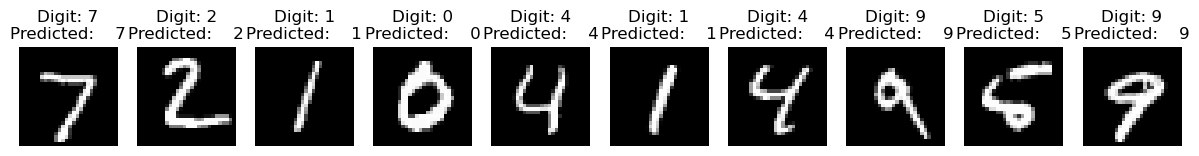

In [12]:
#X_test = X_test.reshape(X_test.shape[0], img_rows*img_cols)
predictions = modelloaded.predict(X_test)

X_test = X_test.reshape(X_test.shape[0], img_rows, img_cols,1)

plt.figure(figsize=(15, 15)) 
for i in range(10):    
    ax = plt.subplot(2, 10, i + 1)    
    plt.imshow(X_test[i, :, :, 0], cmap='gray')    
    plt.title("Digit: {}\nPredicted:    {}".format(np.argmax(Y_test[i]), np.argmax(predictions[i])))    
    plt.axis('off') 
plt.show()

15
['uno.png', 'sei.png', 'sette.png', 'otto.png', 'cinque.png', 'due.png', 'quattro_eur.png', 'quattro_usa.png', 'tre.png', 'nove1.png', 'nove2.png', 'tremoved.png', 'unomoved.png', 'tremv.png', 'ottomvd.png']
uno.png
Image size: 28x28
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
0 0
sei.png
Image size: 28x28
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
0 1
sette.png
Image size: 28x28
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
0 2
otto.png
Image size: 28x28
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


/home/td/miniconda3/envs/dl/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_5
Received: inputs=('Tensor(shape=(1, 28, 28))',)
  warnings.warn(msg)


1 0
cinque.png
Image size: 28x28
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1 1
due.png
Image size: 28x28
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1 2
quattro_eur.png
Image size: 28x28
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
2 0
quattro_usa.png
Image size: 28x28
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2 1
tre.png
Image size: 28x28
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2 2
nove1.png
Image size: 28x28
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
3 0
nove2.png
Image size: 28x28
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
3 1
tremoved.png
Image size: 28x28
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
3 2
unomoved.png
Image size: 28x28
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
4 0
tremv.png
Image size: 28x28
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
4 1
ottomvd.png
Image size: 28x28
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
4 2


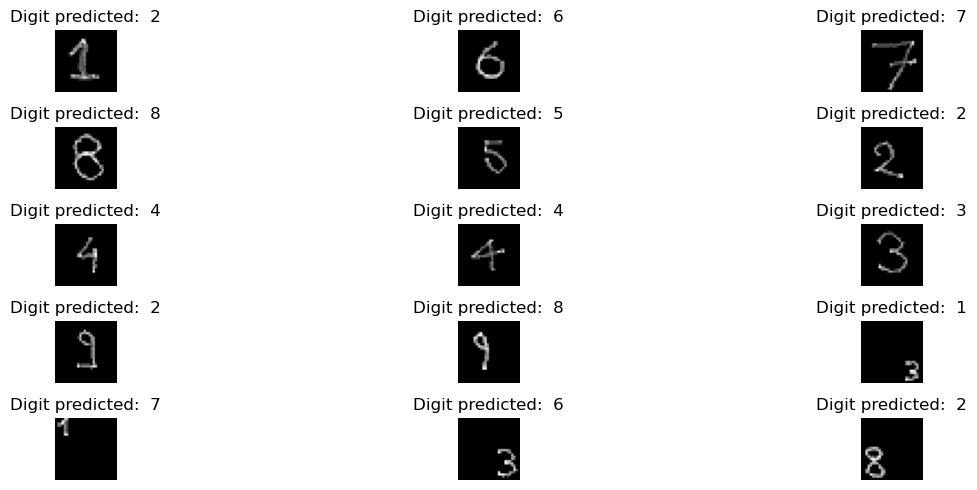

In [13]:
files=os.listdir('images/')
print(len(files))
print(files)
fig, ax =plt.subplots((len(files)+2)//3, 3, figsize=(15, 5))  

for n,file in enumerate(files):
    print(file)
    digit_filename = "./images/"+file
    digit_in = Image.open(digit_filename).convert('L')
    #digit_in = Image.open("8b.png").convert('L') #ON GOOGLE COLAB INSERT THE NAME OF THE UPLOADED FILE

    ydim, xdim = digit_in.size
    print("Image size: "+str(xdim)+"x"+str(ydim))
    pix=digit_in.load();
    data = np.zeros((xdim, ydim))
    for j in range(ydim):
        for i in range(xdim):
            data[i,j]=pix[j,i]

    data /= 255
    # print(data.shape)
    # data = data.reshape(1,xdim*ydim)
    data1=data
    data1 = data1.reshape(1, xdim,ydim)
    # print(data1.shape)
    pred_0 = modelloaded.predict([data1])

    print(n//3, n%3)
    ax[n//3, n%3].imshow(data, cmap='gray')    
    ax[n//3, n%3].set_title("Digit predicted:  {}".format(np.argmax(pred_0)))
    ax[n//3, n%3].axis('off') 
plt.tight_layout()
plt.show()

In [14]:
layer_index=0
for layer in modelloaded.layers:
    print(layer_index, layer.name)
    layer_index+=1

0 conv2d_10
1 max_pooling2d_10
2 dropout_5
3 conv2d_11
4 max_pooling2d_11
5 flatten_5
6 dense_10
7 dense_11


(5, 5, 1, 10)


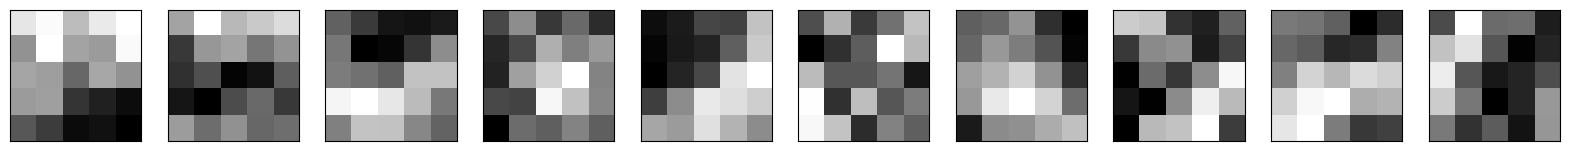

In [15]:
# layer_index should be the index of a convolutional layer
layer_index=0
# retrieve weights from the convolutional hidden layer
filters, biases = modelloaded.layers[layer_index].get_weights()
# normalize filter values to 0-1 so we can visualize them
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)
print(filters.shape)

# plot filters
n_filters, ix = filters.shape[3], 1
plt.figure(figsize=(20, 3))
for i in range(n_filters):
    # get the filter
    f = filters[:, :, :, i]
    # specify subplot and turn of axis
    ax = plt.subplot(1,n_filters, ix)
    ax.set_xticks([])
    ax.set_yticks([])
    # plot filter channel in grayscale
    plt.imshow(f[:, :, 0], cmap='gray')
    ix += 1
# show the figure
plt.show()